**Canny Edge**

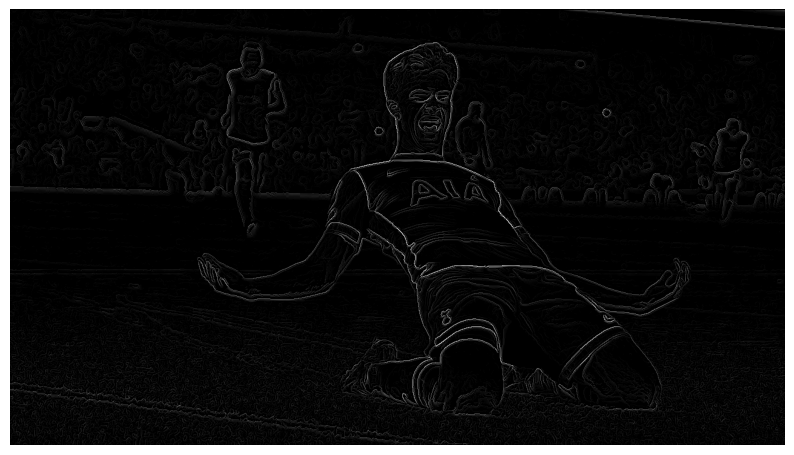

In [2]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

def Canny_detector(img, weak_th=None, strong_th=None):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.GaussianBlur(img, (5, 5), 1.4)
    gx = cv2.Sobel(np.float32(img), cv2.CV_64F, 1, 0, 3)
    gy = cv2.Sobel(np.float32(img), cv2.CV_64F, 0, 1, 3)
    mag, ang = cv2.cartToPolar(gx, gy, angleInDegrees=True)
    mag_max = np.max(mag)

    if not weak_th:
        weak_th = mag_max * 0.1
    if not strong_th:
        strong_th = mag_max * 0.5

    height, width = img.shape
    for i_x in range(width):
        for i_y in range(height):
            grad_ang = abs(ang[i_y, i_x] - 180) if abs(ang[i_y, i_x]) > 180 else abs(ang[i_y, i_x])
            offsets = [((-1, 0), (1, 0)), ((-1, -1), (1, 1)), ((0, -1), (0, 1)), ((-1, 1), (1, -1)), ((-1, 0), (1, 0))]
            index = min(int(grad_ang // 45), 4)
            (dx1, dy1), (dx2, dy2) = offsets[index]

            neighb_1_x, neighb_1_y = i_x + dx1, i_y + dy1
            neighb_2_x, neighb_2_y = i_x + dx2, i_y + dy2
            if 0 <= neighb_1_x < width and 0 <= neighb_1_y < height and mag[i_y, i_x] < mag[neighb_1_y, neighb_1_x]:
                mag[i_y, i_x] = 0
                continue
            if 0 <= neighb_2_x < width and 0 <= neighb_2_y < height and mag[i_y, i_x] < mag[neighb_2_y, neighb_2_x]:
                mag[i_y, i_x] = 0

    weak_ids = np.zeros_like(img)
    strong_ids = np.zeros_like(img)
    ids = np.zeros_like(img)
    for i_x in range(width):
        for i_y in range(height):
            grad_mag = mag[i_y, i_x]
            if grad_mag < weak_th:
                mag[i_y, i_x] = 0
            elif strong_th > grad_mag >= weak_th:
                ids[i_y, i_x] = 1
            else:
                ids[i_y, i_x] = 2

    return mag

frame = cv2.imread('berg.png')
canny_img = Canny_detector(frame, weak_th=10, strong_th=220)

plt.figure(figsize=(10, 10))
plt.imshow(canny_img, cmap='gray')
plt.axis('off')
plt.show()


**Laplacian Of Gaussian**

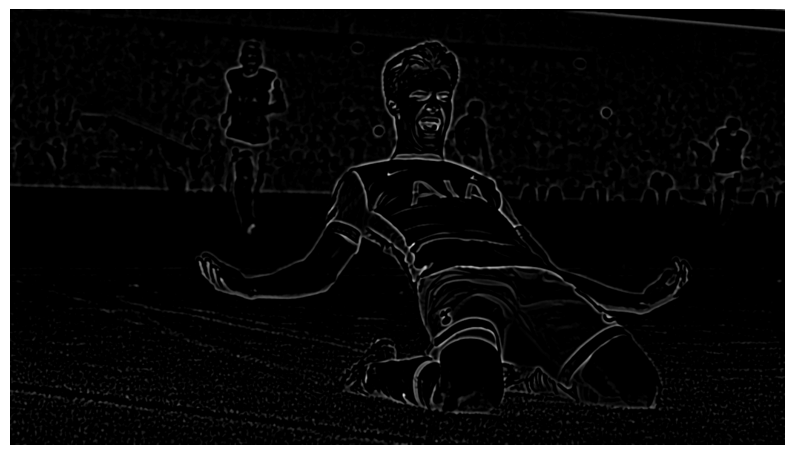

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def LoG_filter_opencv(image, sigma, size=None):
    if size is None:
        size = int(6 * sigma + 1) if sigma >= 1 else 7
    if size % 2 == 0:
        size += 1
        
    x, y = np.meshgrid(np.arange(-size//2 + 1, size//2 + 1), np.arange(-size//2 + 1, size//2 + 1))
    
    kernel = -(1/(np.pi * sigma**4)) * (1 - ((x**2 + y**2) / (2 * sigma**2))) * np.exp(- (x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / np.sum(np.abs(kernel)) 

    result = cv2.filter2D(image, -1, kernel) 
    return result

plt.figure(figsize=(10, 10))
image = cv2.imread(r"berg.png", cv2.IMREAD_GRAYSCALE)
sigma = 2.0
filtered_image = LoG_filter_opencv(image, sigma)

filtered_image = cv2.convertScaleAbs(filtered_image)
plt.imshow(filtered_image, cmap="gray")
plt.axis("off")
plt.show()


**Difference Of Gaussian**

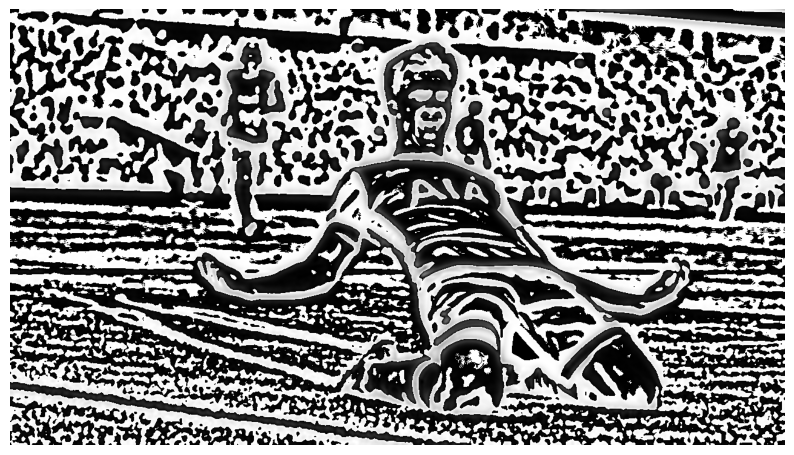

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def DoG_filter_opencv(image, sigma1, sigma2, size=None):
    if size is None:
        size = int(6 * max(sigma1, sigma2) + 1) if max(sigma1, sigma2) >= 1 else 7
    if size % 2 == 0:
        size += 1
    
    gaussian1 = cv2.GaussianBlur(image, (size, size), sigma1)
    gaussian2 = cv2.GaussianBlur(image, (size, size), sigma2)
    
    result = gaussian1 - gaussian2
    return result

plt.figure(figsize=(10, 10))
image = cv2.imread(r"berg.png", cv2.IMREAD_GRAYSCALE)
sigma1 = 2.0
sigma2 = 7.0
filtered_image = DoG_filter_opencv(image, sigma1, sigma2)

filtered_image = cv2.convertScaleAbs(filtered_image)
plt.imshow(filtered_image, cmap="gray")
plt.axis("off")
plt.show()
